In [25]:
import numpy as np
import control as ctrl
import matplotlib.pyplot as plt

import utils

### 1)

\begin{align*}
  \dot{v} &= -0.25v - 2r \\
  \dot{r} &= 0.08v - 0.35r + 0.62\tau_r \\
  \dot{\psi} &= r
\end{align*}

Tomando estado $\mathbf{x} = \begin{bmatrix} v & r & \psi \end{bmatrix}^T$, entrada $u_c = \tau_r$ y salida $y = \psi$, queda:

\begin{align*}
  \dot{\mathbf{x}} &= 
  \begin{bmatrix}
    -0.25 & -2 & 0 \\
    0.08 & -0.35 & 0 \\
    0 & 1 & 0
  \end{bmatrix}
  \mathbf{x} +
  \begin{bmatrix} 0 \\ 0.62 \\ 0 \end{bmatrix}
  u_c\\
  y &= \begin{bmatrix} 0 & 0 & 1 \end{bmatrix}
  \mathbf{x}
\end{align*}


### 2)

Para verificar que sea posible diseñar un controlador, se busca que la matriz de controlabilidad $\mathcal{C}$ sea de rango completo. 

En este caso de $3\times3$ se busca:

$$Rg(\mathcal{C}) = Rg(\begin{bmatrix} \mathbf{B} & \mathbf{A}\mathbf{B} & \mathbf{A}^2\mathbf{B} \end{bmatrix}) = 3$$

In [26]:
A = np.array([
    [-0.25, -2, 0],
    [0.08, -0.35, 0],
    [0, 1, 0]
])

B = np.array([
    [0],
    [0.62],
    [0]
])

utils.check_controllability(A, B)

Matriz de controlabilidad:
[[ 0.      -1.24     0.744  ]
 [ 0.62    -0.217   -0.02325]
 [ 0.       0.62    -0.217  ]]

Rango de C: 3
Dimensión del sistema: 3

El sistema es controlable: True


### 3)

Para agregar acción integral y poder rastrear una referencia $\psi_{ref}$, se aumenta el estado con un integrador:

$$\mathbf{x}_a = \begin{bmatrix} v \\ r \\ \psi \\ \xi \end{bmatrix}, \quad \dot{\xi} = \psi_{ref} - \psi$$

El sistema aumentado queda:

\begin{align*}
  \dot{\mathbf{x}}_a &= \mathbf{A}_a\mathbf{x}_a + \mathbf{B}_a\tau_r + \mathbf{E}_a\psi_{ref}
\end{align*}

Donde:

$$\mathbf{A}_a = \begin{bmatrix}
  -0.25 & -2 & 0 & 0 \\
  0.08 & -0.35 & 0 & 0 \\
  0 & 1 & 0 & 0 \\
  0 & 0 & -1 & 0
\end{bmatrix}, \quad
\mathbf{B}_a = \begin{bmatrix} 0 \\ 0.62 \\ 0 \\ 0 \end{bmatrix}, \quad
\mathbf{E}_a = \begin{bmatrix} 0 \\ 0 \\ 0 \\ 1 \end{bmatrix}

### 4)

In [ ]:
C = np.array([[0, 0, 1]])

A_a = np.hstack([
    np.vstack([A, -C]), np.zeros((4, 1))
])

B_a = np.vstack([B, np.array([[0]])])

E_a = np.array([[0], [0], [0], [1]])

utils.check_controllability(A_a, B_a)

Matriz de controlabilidad:
[[ 0.        -1.24       0.744     -0.1395   ]
 [ 0.62      -0.217     -0.02325    0.0676575]
 [ 0.         0.62      -0.217     -0.02325  ]
 [ 0.         0.        -0.62       0.217    ]]

Rango de C: 4
Dimensión del sistema: 4

El sistema es controlable: True


### 5)

In [28]:
poles = [-1.5, -2.0, -2.5, -3.0]

Ka = ctrl.place(A_a, B_a, poles)

A_cl = A_a - B_a @ Ka
cl_poles = np.linalg.eigvals(A_cl)

print("\nGanancia de realimentación de estados Ka = [kv, kr, kpsi, ki]:")
print(Ka)


Ganancia de realimentación de estados Ka = [kv, kr, kpsi, ki]:
[[-174.51814516   13.5483871  -304.83870968 -145.16129032]]


### 6)

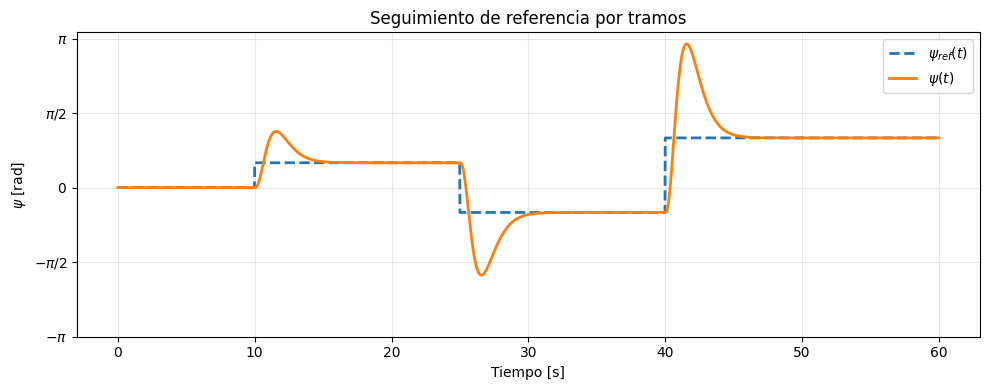

In [29]:
T = np.linspace(0, 60, 3001)
X0 = np.array([0.0, 0.0, 0.0, 0.0])

psi_ref = np.zeros_like(T)
psi_ref[(T >= 10) & (T < 25)] = np.pi/6
psi_ref[(T >= 25) & (T < 40)] = -np.pi/6
psi_ref[(T >= 40) & (T <= 60)] = np.pi/3

A_cl = A_a - B_a @ Ka
sys_cl = ctrl.ss(A_cl, E_a, np.eye(4), np.zeros((4, 1)))
    
T_sim, yout = ctrl.forced_response(sys_cl, T, psi_ref, X0)

plt.figure(figsize=(10, 4))
plt.plot(T_sim, psi_ref, '--', label=r'$\psi_{ref}(t)$', linewidth=2)
plt.plot(T_sim, yout[2, :], label=r'$\psi(t)$', linewidth=2)
plt.xlabel('Tiempo [s]')
plt.ylabel(r'$\psi$ [rad]')
plt.title('Seguimiento de referencia por tramos')
plt.grid(True, alpha=0.3)
plt.legend()
plt.yticks(
    [-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
    [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$']
)
plt.tight_layout()
plt.show()


### 7)

In [30]:
# Estados simulados
v = yout[0, :]
r = yout[1, :]
psi = yout[2, :]
xi = yout[3, :]

# Error de seguimiento
e = psi_ref - psi

# Señal de control: tau_r = -Ka * xa
tau_r = -(Ka @ yout).flatten()

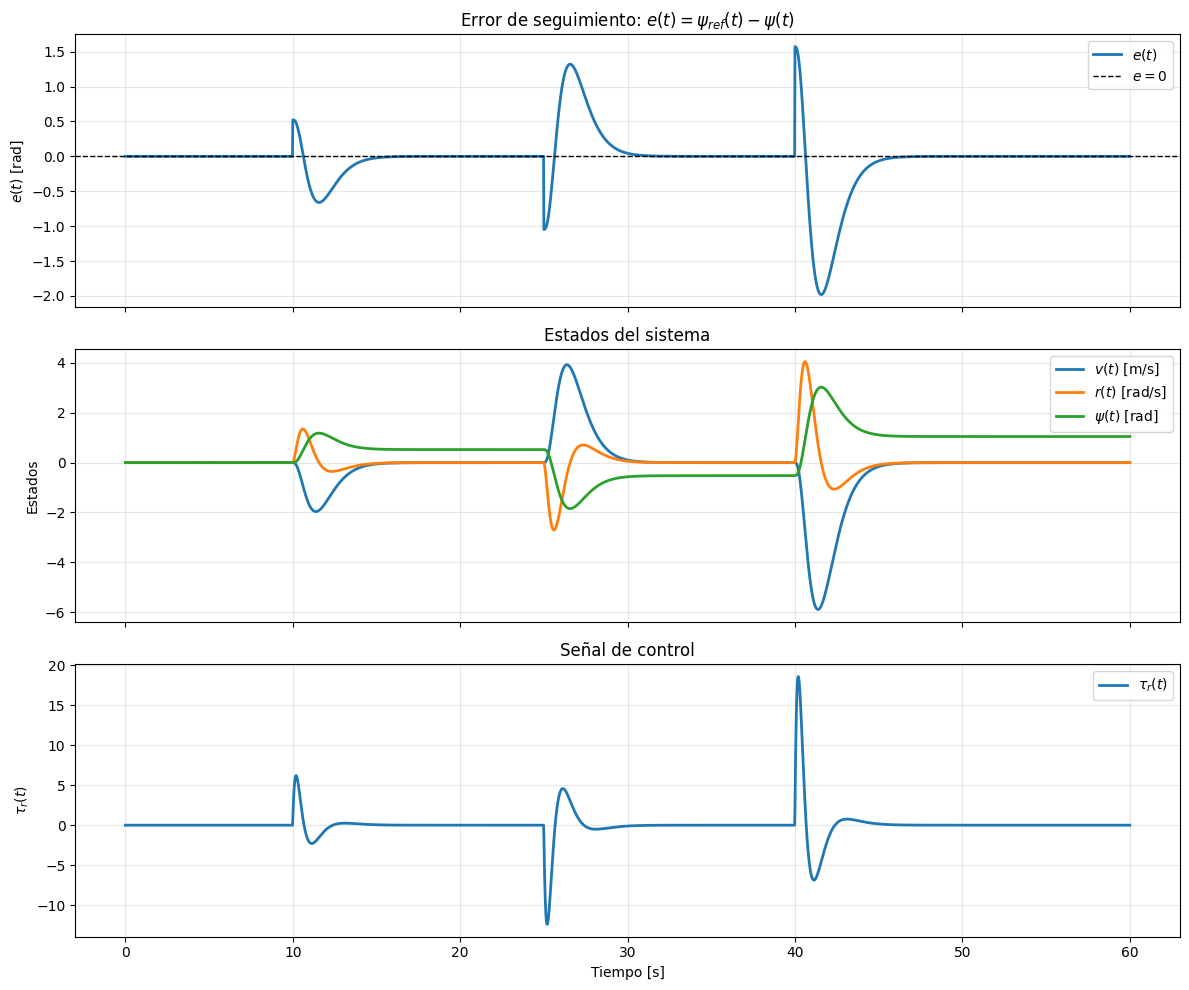

In [31]:
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Error de seguimiento
axs[0].plot(T_sim, e, linewidth=2, label=r'$e(t)$')
axs[0].axhline(0, color='black', linestyle='--', linewidth=1, label=r'$e=0$')
axs[0].set_ylabel(r'$e(t)$ [rad]')
axs[0].set_title(r'Error de seguimiento: $e(t)=\psi_{ref}(t)-\psi(t)$')
axs[0].grid(True, alpha=0.3)
axs[0].legend()

# Estados del sistema
axs[1].plot(T_sim, v, label=r'$v(t)$ [m/s]', linewidth=2)
axs[1].plot(T_sim, r, label=r'$r(t)$ [rad/s]', linewidth=2)
axs[1].plot(T_sim, psi, label=r'$\psi(t)$ [rad]', linewidth=2)
# axs[1].plot(T_sim, psi_ref, '--', label=r'$\psi_{ref}(t)$ [rad]', linewidth=2)
axs[1].set_ylabel('Estados')
axs[1].set_title('Estados del sistema')
axs[1].legend()
axs[1].grid(True, alpha=0.3)
axs[1].legend()

# Señal de control
axs[2].plot(T_sim, tau_r, linewidth=2, label=r'$\tau_r(t)$')
axs[2].set_xlabel('Tiempo [s]')
axs[2].set_ylabel(r'$\tau_r(t)$')
axs[2].set_title('Señal de control')
axs[2].grid(True, alpha=0.3)
axs[2].legend()

plt.tight_layout()
plt.show()

In [32]:
print("Máximo error absoluto:", np.max(np.abs(e)))
print("Máximo tau_r absoluto:", np.max(np.abs(tau_r)))
print("Máximo v absoluto:", np.max(np.abs(v)))
print("Máximo r absoluto:", np.max(np.abs(r)))

Máximo error absoluto: 1.9810266825708769
Máximo tau_r absoluto: 18.598933919522267
Máximo v absoluto: 5.890279226158989
Máximo r absoluto: 4.053688142183347


### 8)  FALTA

* Si la embarcaci´on logra seguir la referencia de rumbo.
* Si el error estacionario es nulo.
* Si la velocidad de respuesta del sistema es adecuada para el problema.
* Si la suavidad de la se˜nal de control.
* Si los valores m´aximos requeridos de τr.
* C´omo cambia la respuesta al modificar la ubicaci´on de los polos (para esto, puede graficar ambos resultados).
* Las posibles limitaciones f´ısicas del actuador.